In [1]:
# ============================================================
# PYTHON PORTFOLIO – CONSTRUCTION OPERATIONS REPORTING & ANALYTICS
# ============================================================
# Complete end-to-end workflow: data validation, preparation,
# KPI reporting, business analysis, visualizations, and exports.

---
    1.0 Data Import
    Import project data and prepare it for analysis.
---

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from IPython.display import display
from openpyxl import load_workbook
from openpyxl.styles import Alignment, Font

In [3]:
# Load operational records from the project dataset
try:
    df = pd.read_csv("Operations_Master_Log.csv")
    print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
except FileNotFoundError:
    print("Error: Operations_Master_Log.csv not found in current directory.")
    print("Please place the CSV file in the same folder as this script.")
    exit()

print("\nFirst 5 rows:")
display(df.head())

Dataset loaded: 348 rows, 21 columns

First 5 rows:


,Log_ID,Date,Day,Week,Month,Category,Item,Quantity,Unit,Operation,...,Notes,Source,Labour_Cost_NGN,Mixer_Hours,Vibrator_Hours,Excavation_Rate,Excavation_Cost_NGN,Base_Casting_Cost_NGN,Wall_Casting_Cost_NGN,Water_Trip_Cost_NGN
0,LOG001,1/27/2026,Tuesday,W5,26-Jan,Work,Excavation,125.0,m,Completed,...,Line drain excavation,Group,0,0,0,0,100000,0,0,0
1,LOG002,1/27/2026,Tuesday,W5,26-Jan,Cost,Labour Cost,15000.0,NGN,Paid,...,Labour for excavation,Group,15000,0,0,0,0,0,0,0
2,LOG003,1/28/2026,Wednesday,W5,26-Jan,Work,Excavation,163.4,m,Completed,...,Daily excavation,Group,0,0,0,0,130720,0,0,0
3,LOG004,1/28/2026,Wednesday,W5,26-Jan,Cost,Labour Cost,18000.0,NGN,Paid,...,Labour for excavation,Group,18000,0,0,0,0,0,0,0
4,LOG005,1/29/2026,Thursday,W5,26-Jan,Work,Excavation,165.0,m,Completed,...,Daily excavation,Group,0,0,0,0,132000,0,0,0


---
    2.0 Check the data quality
    Look for missing values, duplicates.
---

In [4]:
print("\n" + "="*20)
print("DATA QUALITY REVIEW")
print("="*20)

print(f"Dataset shape: {df.shape[0]} records, {df.shape[1]} columns")

print("\nMissing values:")
print(df.isnull().sum())

print(f"\nDuplicate records: {df.duplicated().sum()}")

print("\nDate range:")
print(f"  Start: {df['Date'].min()}")
print(f"  End:   {df['Date'].max()}")

print(f"\nNegative quantities: {df[df['Quantity'] < 0].shape[0]}")

print("\nData types:")
print(df.dtypes)


DATA QUALITY REVIEW
Dataset shape: 348 records, 21 columns

Missing values:
Log_ID                   0
Date                     0
Day                      0
Week                     0
Month                    0
Category                 0
Item                     0
Quantity                 0
Unit                     0
Operation                0
Location                 0
Notes                    0
Source                   0
Labour_Cost_NGN          0
Mixer_Hours              0
Vibrator_Hours           0
Excavation_Rate          0
Excavation_Cost_NGN      0
Base_Casting_Cost_NGN    0
Wall_Casting_Cost_NGN    0
Water_Trip_Cost_NGN      0
dtype: int64

Duplicate records: 0

Date range:
  Start: 1/27/2026
  End:   4/8/2026

Negative quantities: 0

Data types:
Log_ID                    object
Date                      object
Day                       object
Week                      object
Month                     object
Category                  object
Item                      object
Qua

---
    3.0 DATA PREPARATION
    Handle missing values, convert data types, and standardize formats.
---


In [5]:
print("\n" + "="*20)
print("DATA PREPARATION")
print("="*20)

# Fill missing units
df["Unit"] = df["Unit"].fillna("Unknown")

# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Convert numeric columns
numeric_columns = [
    "Quantity", "Labour_Cost_NGN", "Mixer_Hours", "Vibrator_Hours",
    "Excavation_Rate", "Excavation_Cost_NGN", "Base_Casting_Cost_NGN",
    "Wall_Casting_Cost_NGN", "Water_Trip_Cost_NGN"
]

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print(f"Preparation complete. {len(df)} records ready for analysis.")
display(df.head())


DATA PREPARATION
Preparation complete. 348 records ready for analysis.


,Log_ID,Date,Day,Week,Month,Category,Item,Quantity,Unit,Operation,...,Notes,Source,Labour_Cost_NGN,Mixer_Hours,Vibrator_Hours,Excavation_Rate,Excavation_Cost_NGN,Base_Casting_Cost_NGN,Wall_Casting_Cost_NGN,Water_Trip_Cost_NGN
0,LOG001,2026-01-27,Tuesday,W5,26-Jan,Work,Excavation,125.0,m,Completed,...,Line drain excavation,Group,0,0,0,0,100000,0,0,0
1,LOG002,2026-01-27,Tuesday,W5,26-Jan,Cost,Labour Cost,15000.0,NGN,Paid,...,Labour for excavation,Group,15000,0,0,0,0,0,0,0
2,LOG003,2026-01-28,Wednesday,W5,26-Jan,Work,Excavation,163.4,m,Completed,...,Daily excavation,Group,0,0,0,0,130720,0,0,0
3,LOG004,2026-01-28,Wednesday,W5,26-Jan,Cost,Labour Cost,18000.0,NGN,Paid,...,Labour for excavation,Group,18000,0,0,0,0,0,0,0
4,LOG005,2026-01-29,Thursday,W5,26-Jan,Work,Excavation,165.0,m,Completed,...,Daily excavation,Group,0,0,0,0,132000,0,0,0


---
    4.0 FEATURE ENGINEERING
    Create reporting metrics used throughout the analysis.
---


In [6]:
print("\n" + "="*20)
print("FEATURE ENGINEERING")
print("="*20)

# Total equipment hours
df["Total_Equipment_Hours"] = (
    df["Mixer_Hours"].fillna(0) + 
    df["Vibrator_Hours"].fillna(0)
)

# Total project cost
df["Total_Cost_NGN"] = (
    df["Labour_Cost_NGN"].fillna(0) +
    df["Excavation_Cost_NGN"].fillna(0) +
    df["Base_Casting_Cost_NGN"].fillna(0) +
    df["Wall_Casting_Cost_NGN"].fillna(0) +
    df["Water_Trip_Cost_NGN"].fillna(0)
)

# Month extraction
df["Month"] = df["Date"].dt.to_period("M").astype(str)

print("New features created:")
print("  - Total_Equipment_Hours")
print("  - Total_Cost_NGN")
print("  - Month")
display(df.head())


FEATURE ENGINEERING
New features created:
  - Total_Equipment_Hours
  - Total_Cost_NGN
  - Month


,Log_ID,Date,Day,Week,Month,Category,Item,Quantity,Unit,Operation,...,Labour_Cost_NGN,Mixer_Hours,Vibrator_Hours,Excavation_Rate,Excavation_Cost_NGN,Base_Casting_Cost_NGN,Wall_Casting_Cost_NGN,Water_Trip_Cost_NGN,Total_Equipment_Hours,Total_Cost_NGN
0,LOG001,2026-01-27,Tuesday,W5,2026-01,Work,Excavation,125.0,m,Completed,...,0,0,0,0,100000,0,0,0,0,100000
1,LOG002,2026-01-27,Tuesday,W5,2026-01,Cost,Labour Cost,15000.0,NGN,Paid,...,15000,0,0,0,0,0,0,0,0,15000
2,LOG003,2026-01-28,Wednesday,W5,2026-01,Work,Excavation,163.4,m,Completed,...,0,0,0,0,130720,0,0,0,0,130720
3,LOG004,2026-01-28,Wednesday,W5,2026-01,Cost,Labour Cost,18000.0,NGN,Paid,...,18000,0,0,0,0,0,0,0,0,18000
4,LOG005,2026-01-29,Thursday,W5,2026-01,Work,Excavation,165.0,m,Completed,...,0,0,0,0,132000,0,0,0,0,132000


---
    5.0 PROJECT KPI SUMMARY
    High-level overview of project performance.
---

In [7]:
print("\n" + "="*20)
print("PROJECT KPI SUMMARY")
print("="*20)

print(f"Total Records:              {len(df):,}")
print(f"Active Locations:           {df['Location'].nunique():,}")
print(f"Activity Categories:        {df['Category'].nunique():,}")
print(f"Tracked Activities:         {df['Item'].nunique():,}")
print(f"Project Start Date:         {df['Date'].min().strftime('%Y-%m-%d')}")
print(f"Project End Date:           {df['Date'].max().strftime('%Y-%m-%d')}")
print(f"Project Duration (Days):    {(df['Date'].max() - df['Date'].min()).days:,}")
print(f"Total Project Cost:         ₦{df['Total_Cost_NGN'].sum():,.2f}")
print(f"Total Labour Cost:          ₦{df['Labour_Cost_NGN'].sum():,.2f}")
print(f"Total Equipment Hours:      {df['Total_Equipment_Hours'].sum():,.2f}")


PROJECT KPI SUMMARY
Total Records:              348
Active Locations:           4
Activity Categories:        6
Tracked Activities:         24
Project Start Date:         2026-01-27
Project End Date:           2026-04-30
Project Duration (Days):    93
Total Project Cost:         ₦4,487,370.00
Total Labour Cost:          ₦744,500.00
Total Equipment Hours:      396.00


---
    6.0 COST ANALYSIS
    Breaking down costs by location and activity.
---

In [8]:
print("\n" + "="*20)
print("COST BY LOCATION")
print("="*20)

cost_by_location = (
    df.groupby("Location")["Total_Cost_NGN"]
    .sum()
    .sort_values(ascending=False)
)
print(cost_by_location)


COST BY LOCATION
Location
Site B          2274850
Site A          2172520
Road Section      40000
Main Store            0
Name: Total_Cost_NGN, dtype: int64


In [9]:
print("\n" + "="*25)
print("TOP 10 COST ACTIVITIES")
print("="*25)

top_cost_activities = (
    df.groupby("Item")["Total_Cost_NGN"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
print(top_cost_activities)


TOP 10 COST ACTIVITIES
Item
Wall Casting           1021500
Excavation              921620
Excavation Repair       779500
Labour Cost             744500
Water Supply            514000
Base Casting            506250
Sharp Sand                   0
Y8 Rebar Delivered           0
Y16 Remaining                0
Y16 Rebar Delivered          0
Name: Total_Cost_NGN, dtype: int64


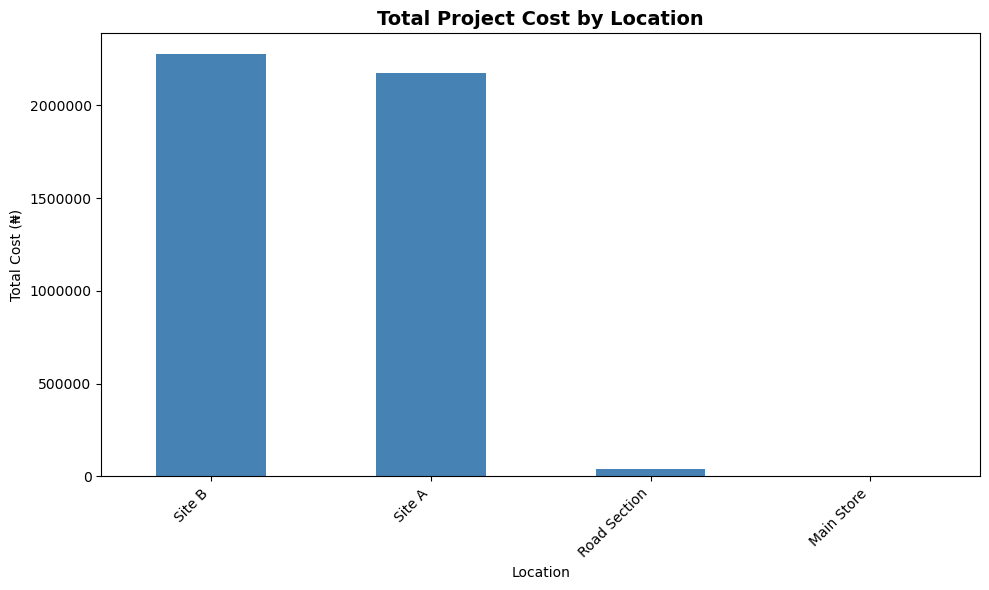

In [10]:
# Cost by location - bar chart
fig, ax = plt.subplots(figsize=(10, 6))
cost_by_location.plot(kind="bar", color="steelblue", ax=ax)
ax.set_title("Total Project Cost by Location", fontsize=14, fontweight="bold")
ax.set_xlabel("Location")
ax.set_ylabel("Total Cost (₦)")
ax.ticklabel_format(style="plain", axis="y")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("outputs/charts/cost_by_location.png")
plt.show()

---
    7.0 PRODUCTIVITY ANALYSIS
    Measuring work output across locations and weeks.
---

In [11]:
print("\n" + "="*25)
print("PRODUCTIVITY BY LOCATION")
print("="*25)

productivity = (
    df[df["Category"] == "Work"]
    .groupby("Location")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)
print(productivity)


PRODUCTIVITY BY LOCATION
Location
Site A    1235.9
Site B     692.0
Name: Quantity, dtype: float64


In [12]:
print("\n" + "="*25)
print("WEEKLY PRODUCTIVITY")
print("="*25)

weekly_productivity = (
    df.groupby("Week")["Quantity"]
    .sum()
    .sort_index()
)
print(weekly_productivity)



WEEKLY PRODUCTIVITY
Week
W10    117597.4
W11    100808.8
W12     24140.9
W13     28191.0
W14     68376.5
W15     18076.5
W16     28034.0
W17     12005.0
W18       139.5
W5      91809.4
W6      26539.5
W7      31281.0
W8     110808.0
W9      95103.8
Name: Quantity, dtype: float64


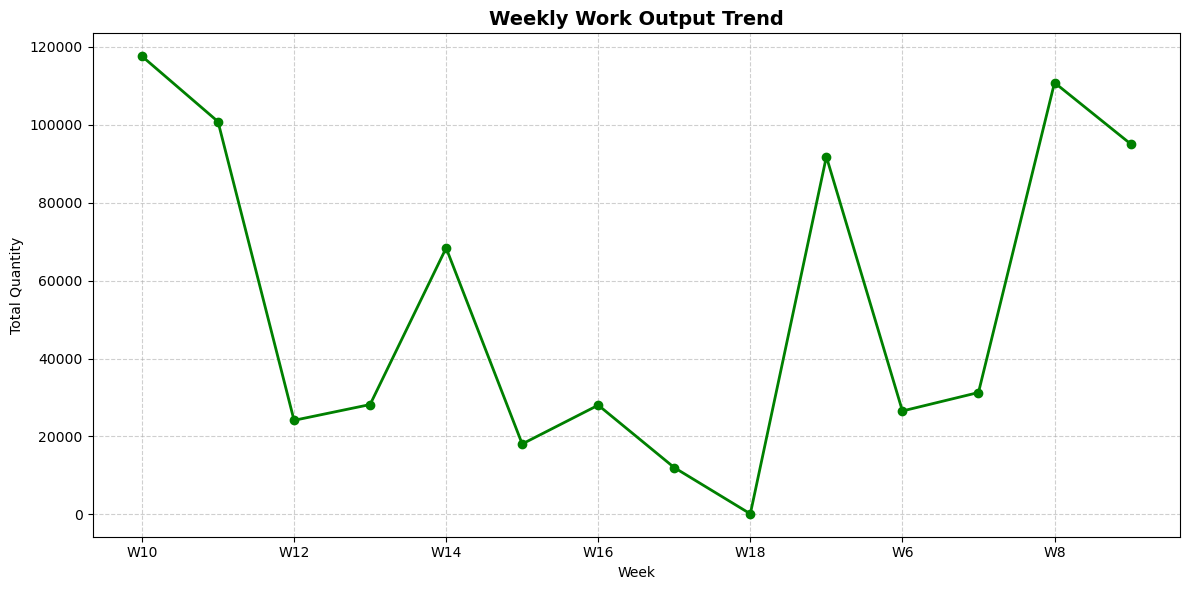

In [13]:
# Weekly productivity trend
fig, ax = plt.subplots(figsize=(12, 6))
weekly_productivity.plot(kind="line", marker="o", color="green", linewidth=2, ax=ax)
ax.set_title("Weekly Work Output Trend", fontsize=14, fontweight="bold")
ax.set_xlabel("Week")
ax.set_ylabel("Total Quantity")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("outputs/charts/weekly_productivity.png")
plt.show()

In [14]:
print("\n" + "="*20)
print("MATERIAL CONSUMPTION")
print("="*20)

materials = (
    df[df["Category"] == "Material"]
    .groupby("Item")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)
print(materials)



MATERIAL CONSUMPTION
Item
Cement Delivered       950.0
Y8 Rebar Delivered     840.0
Y10 Rebar Delivered    402.0
Y8 Remaining            92.0
Y16 Rebar Delivered     54.0
Cement Missing          36.0
Y10 Remaining           25.0
Cement Remaining         4.0
Y16 Remaining            2.0
Cement Spillage          1.0
Name: Quantity, dtype: float64


---
    9.0 EQUIPMENT UTILISATION ANALYSIS
    Analyzing mixer and vibrator usage by site.
---

In [15]:
print("\n" + "="*30)
print("EQUIPMENT UTILISATION BY SITE")
print("="*30)

equipment = (
    df.groupby("Location")
    [["Mixer_Hours", "Vibrator_Hours"]]
    .sum()
    .fillna(0)
)
print(equipment)


EQUIPMENT UTILISATION BY SITE
              Mixer_Hours  Vibrator_Hours
Location                                 
Main Store              0               0
Road Section            0               0
Site A                 99              67
Site B                136              94


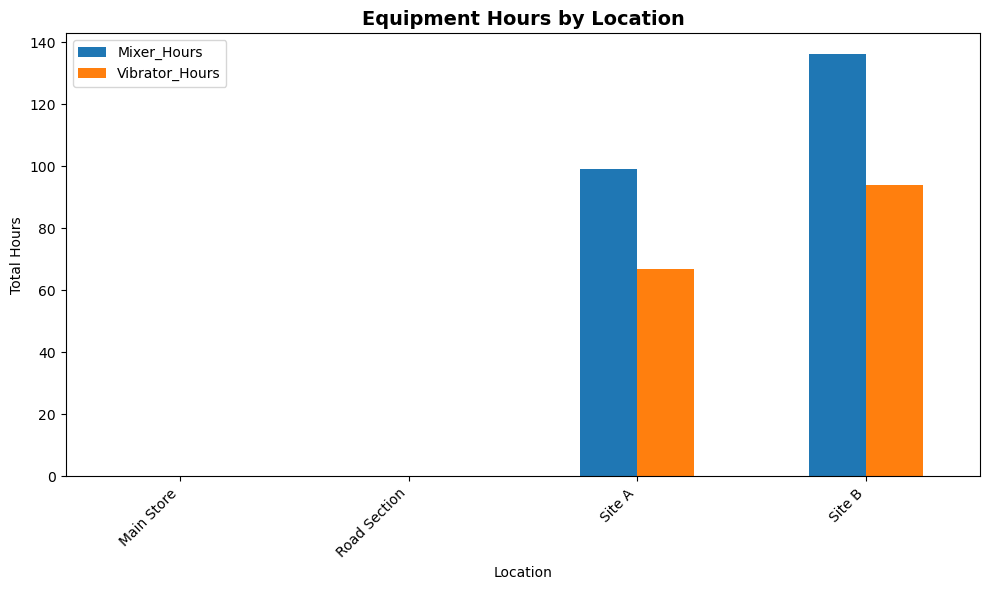

In [16]:
# Equipment utilisation chart
fig, ax = plt.subplots(figsize=(10, 6))
equipment.plot(kind="bar", ax=ax)
ax.set_title("Equipment Hours by Location", fontsize=14, fontweight="bold")
ax.set_xlabel("Location")
ax.set_ylabel("Total Hours")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("outputs/charts/equipment_by_location.png")
plt.show()


--- 
    10.0 CEMENT RECONCILIATION
    Tracking cement deliveries, usage, and losses.
---

In [17]:
print("\n" + "="*25)
print("CEMENT MOVEMENT SUMMARY")
print("="*25)

cement = df[df["Item"].str.contains("Cement", na=False)]
cement_summary = cement.groupby("Item")["Quantity"].sum()
print(cement_summary)


CEMENT MOVEMENT SUMMARY
Item
Cement Delivered    950.0
Cement Missing       36.0
Cement Remaining      4.0
Cement Spillage       1.0
Cement Used         909.0
Name: Quantity, dtype: float64


In [18]:
# Cement pivot by location
cement_pivot = (
    df[df["Item"].str.contains("Cement", na=False)]
    .pivot_table(
        index="Location",
        columns="Item",
        values="Quantity",
        aggfunc="sum",
        fill_value=0
    )
)
print("\nCement Breakdown by Location:")
print(cement_pivot)


Cement Breakdown by Location:
Item        Cement Delivered  Cement Missing  Cement Remaining  \
Location                                                         
Main Store               0.0             0.0               4.0   
Site A                 450.0            34.0               0.0   
Site B                 500.0             2.0               0.0   

Item        Cement Spillage  Cement Used  
Location                                  
Main Store              1.0          0.0  
Site A                  0.0        382.5  
Site B                  0.0        526.5  


---
    11.0 EXCEPTION REPORTING
    Flagging excavation rate exceptions for quality review.
---                                       

In [19]:
print("\n" + "="*25)
print("EXCAVATION RATE EXCEPTIONS")
print("="*25)

exceptions = df[
    (df["Excavation_Rate"].notna()) &
    (~df["Excavation_Rate"].isin([800, 1000]))
]

print(f"Found {len(exceptions)} excavation rate exceptions")
if len(exceptions) > 0:
    print("\nException Details:")
    print(exceptions[["Date", "Location", "Item", "Quantity", "Excavation_Rate"]].head(10))
else:
    print("All rates are within expected range.")


EXCAVATION RATE EXCEPTIONS
Found 348 excavation rate exceptions

Exception Details:
        Date Location         Item  Quantity  Excavation_Rate
0 2026-01-27   Site A   Excavation     125.0                0
1 2026-01-27   Site A  Labour Cost   15000.0                0
2 2026-01-28   Site A   Excavation     163.4                0
3 2026-01-28   Site A  Labour Cost   18000.0                0
4 2026-01-29   Site A   Excavation     165.0                0
5 2026-01-29   Site A  Labour Cost   18000.0                0
6 2026-01-30   Site B   Excavation     122.4                0
7 2026-01-30   Site B  Labour Cost   14000.0                0
8 2026-01-31   Site B   Excavation     169.6                0
9 2026-01-31   Site B  Labour Cost   18000.0                0


---
    12.0 COST TREND ANALYSIS
    Visualizing spending patterns over time.
---

In [20]:
print("\n" + "="*25)
print("MONTHLY COST TREND")
print("="*25)

monthly_cost = df.groupby("Month")["Total_Cost_NGN"].sum()
print(monthly_cost)


MONTHLY COST TREND
Month
2026-01     737720
2026-02    1766900
2026-03    1830350
2026-04     152400
Name: Total_Cost_NGN, dtype: int64


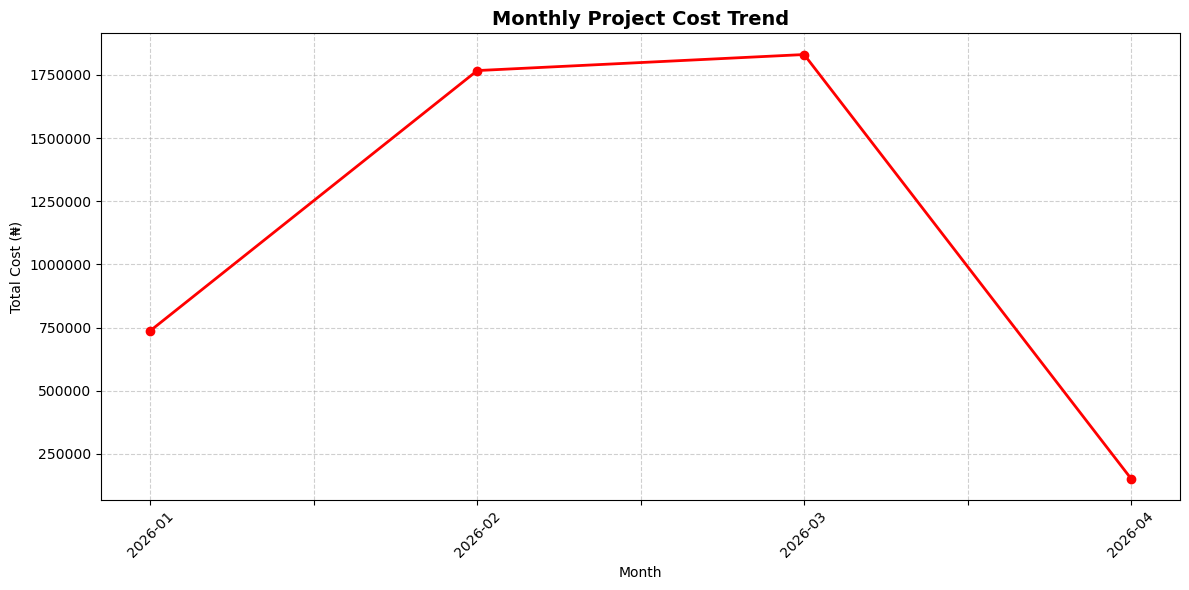

In [21]:
# Monthly cost trend chart
fig, ax = plt.subplots(figsize=(12, 6))
monthly_cost.plot(kind="line", marker="o", color="red", linewidth=2, ax=ax)
ax.set_title("Monthly Project Cost Trend", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Total Cost (₦)")
ax.ticklabel_format(style="plain", axis="y")
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("outputs/charts/monthly_cost_trend.png")
plt.show()

---
    13.0 REPORT EXPORTS
    Export analysis outputs for reporting and dashboard development.
---

In [22]:
print("\n" + "="*20)
print("EXPORTING RESULTS")
print("="*20)

# Create outputs folder
os.makedirs("outputs", exist_ok=True)

# Export CSVs
cost_by_location.to_csv("outputs/csv/cost_by_location.csv")
monthly_cost.to_csv("outputs/csv/monthly_cost_trend.csv")
top_cost_activities.to_csv("outputs/csv/top_cost_activities.csv")
weekly_productivity.to_csv("outputs/csv/weekly_productivity.csv")
equipment.to_csv("outputs/csv/equipment_utilisation.csv")
cement_summary.to_csv("outputs/csv/cement_reconciliation.csv")
materials.to_csv("outputs/csv/material_consumption.csv")
cement_pivot.to_csv("outputs/csv/cement_by_location.csv")

print("All CSVs exported successfully to ./outputs/")
print("   - cost_by_location.csv")
print("   - monthly_cost_trend.csv")
print("   - top_cost_activities.csv")
print("   - weekly_productivity.csv")
print("   - equipment_utilisation.csv")
print("   - cement_reconciliation.csv")
print("   - material_consumption.csv")
print("   - cement_by_location.csv")


EXPORTING RESULTS
All CSVs exported successfully to ./outputs/
   - cost_by_location.csv
   - monthly_cost_trend.csv
   - top_cost_activities.csv
   - weekly_productivity.csv
   - equipment_utilisation.csv
   - cement_reconciliation.csv
   - material_consumption.csv
   - cement_by_location.csv


---
    14.0 EXECUTIVE PROJECT SUMMARY
    Consolidated overview of project performance and operational KPIs.
---

In [33]:
# Ensure the output directory exists
os.makedirs("outputs/reports", exist_ok=True)

print("\n" + "=" * 50)
print("EXECUTIVE PROJECT SUMMARY")
print("=" * 50)

# ---- Calculate averages correctly ----
excavation_filtered = df[(df['Item'] == 'Excavation') & (df['Quantity'] > 0)]
avg_excavation_rate = excavation_filtered['Excavation_Rate'].mean() if not excavation_filtered.empty else 0

summary_data = {
    "Metric": [
        "Total Records",
        "Active Locations",
        "Activity Categories",
        "Tracked Activities",
        "Project Start Date",
        "Project End Date",
        "Project Duration (Days)",
        "Total Project Cost (₦)",
        "Total Labour Cost (₦)",
        "Total Equipment Hours",
        "Total Excavation (m)",
        "Average Excavation Rate (₦/m)",
        "Cement Delivered (Bags)",
        "Cement Used (Bags)",
        "Cement Missing (Bags)",
        "Cement Spillage (Bags)",
        "Cement Remaining (Bags)"
    ],
    "Value": [
        f"{len(df):,}",
        df["Location"].nunique(),
        df["Category"].nunique(),
        df["Item"].nunique(),
        df["Date"].min().strftime("%Y-%m-%d"),
        df["Date"].max().strftime("%Y-%m-%d"),
        f"{(df['Date'].max() - df['Date'].min()).days:,}",
        f"₦{df['Total_Cost_NGN'].sum():,.2f}",
        f"₦{df['Labour_Cost_NGN'].sum():,.2f}",
        f"{df['Total_Equipment_Hours'].sum():,.2f}",
        f"{df[df['Item'] == 'Excavation']['Quantity'].sum():,.2f}",
        f"₦{avg_excavation_rate:,.2f}",
        cement_summary.get("Cement Delivered", 0),
        cement_summary.get("Cement Used", 0),
        cement_summary.get("Cement Missing", 0),
        cement_summary.get("Cement Spillage", 0),
        cement_summary.get("Cement Remaining", 0)
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# ---- Export as Excel with formatting ----
filename = "outputs/reports/project_summary_report.xlsx"
summary_df.to_excel(filename, index=False, sheet_name="Summary")

# Load the workbook and apply professional formatting
wb = load_workbook(filename)
ws = wb["Summary"]

# 1. Bold the headers (row 1)
for cell in ws[1]:
    cell.font = Font(bold=True)

# 2. Right-align the 'Value' column (column B)
for row in ws.iter_rows(min_col=2, max_col=2):
    for cell in row:
        cell.alignment = Alignment(horizontal='right')

# 3. Auto-adjust column widths
for col in ws.columns:
    max_length = 0
    column = col[0].column_letter
    for cell in col:
        try:
            if len(str(cell.value)) > max_length:
                max_length = len(str(cell.value))
        except:
            pass
    adjusted_width = max_length + 2
    ws.column_dimensions[column].width = adjusted_width

wb.save(filename)
print(f"\n✅ Summary report exported to: {filename}")


EXECUTIVE PROJECT SUMMARY
                       Metric         Value
                Total Records           348
             Active Locations             4
          Activity Categories             6
           Tracked Activities            24
           Project Start Date    2026-01-27
             Project End Date    2026-04-30
      Project Duration (Days)            93
       Total Project Cost (₦) ₦4,487,370.00
        Total Labour Cost (₦)   ₦744,500.00
        Total Equipment Hours        396.00
         Total Excavation (m)      1,012.30
Average Excavation Rate (₦/m)         ₦0.00
      Cement Delivered (Bags)         950.0
           Cement Used (Bags)         909.0
        Cement Missing (Bags)          36.0
       Cement Spillage (Bags)           1.0
      Cement Remaining (Bags)           4.0

✅ Summary report exported to: outputs/reports/project_summary_report.xlsx


In [24]:
print("\n" + "="*70)
print("Analysis completed successfully.")
print("All reports and outputs have been generated.")
print("="*70)


Analysis completed successfully.
All reports and outputs have been generated.
